In [1]:
import os
import numpy as np
import pandas as pd
import random
from tqdm import tqdm

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler

In [2]:
from kaggle_secrets import UserSecretsClient
secret_label = "wandb_api_key"
wandb_key = UserSecretsClient().get_secret(secret_label)

In [3]:
import wandb

wandb.login(key=wandb_key)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 22f3002198 (22f3002198-indian-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Prepare data

### Build a metadata dataframe

In [4]:
dataset_root = "/kaggle/input/datasets/suranjandas1990/forest-loss-dataset/dataset"

records = []

regions = ["Meghalaya_2021_2023", "Nagaland_2021_2023"]

for region in regions:

    label_dir = os.path.join(dataset_root, region, "label")

    for fname in tqdm(os.listdir(label_dir)):

        path = os.path.join(label_dir, fname)

        mask = np.load(path)

        change_pixels = mask.sum()
        total_pixels = mask.size

        change_ratio = change_pixels / total_pixels

        records.append({
            "region": region,
            "file": fname,
            "label_path": path,
            "change_pixels": change_pixels,
            "change_ratio": change_ratio
        })

df = pd.DataFrame(records)

100%|██████████| 2431/2431 [00:23<00:00, 101.98it/s]


In [5]:
print("Total samples:", len(df))
df.head()

Total samples: 5778


,region,file,label_path,change_pixels,change_ratio
0,Meghalaya_2021_2023,Siamese_Tiles-0000003328-0000010496.npy,/kaggle/input/datasets/suranjandas1990/forest-...,364.0,0.005554
1,Meghalaya_2021_2023,Siamese_Tiles-0000009216-0000024832.npy,/kaggle/input/datasets/suranjandas1990/forest-...,238.0,0.003632
2,Meghalaya_2021_2023,Siamese_Tiles-0000005376-0000007424.npy,/kaggle/input/datasets/suranjandas1990/forest-...,76.0,0.001160
3,Meghalaya_2021_2023,Siamese_Tiles-0000008704-0000016640.npy,/kaggle/input/datasets/suranjandas1990/forest-...,0.0,0.000000
4,Meghalaya_2021_2023,Siamese_Tiles-0000009984-0000014080.npy,/kaggle/input/datasets/suranjandas1990/forest-...,239.0,0.003647


### Create stratification bins

To handle the high class imbalance that is inherent in the forest change detection data, the continuous change ratio of the patches was binned into meaningful categorical bins that indicate different classes of deforestation intensity, i.e., no change, very sparse, sparse, and moderate to large change. This helps in the structured understanding of the data distribution, as the majority of the data points indicate minimal or no change in the forest area. In addition, a composite stratification key was created by combining the geographic region with the change category, ensuring that the data splitting operations, i.e., the division of the data into training, validation, and test sets, account for diversity in the data as well as the class imbalance problem. This is crucial in avoiding bias in the data, which is necessary for the robustness of the deep learning model.

In [6]:
bins = [0, 1e-6, 0.005, 0.02, 1]
labels = [
    "no_change",
    "very_sparse",
    "sparse",
    "moderate_large"
]

df["change_bin"] = pd.cut(
    df["change_ratio"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df["stratify_key"] = df["region"] + "_" + df["change_bin"].astype(str)

In [7]:
df.sample(5)['stratify_key']

690     Meghalaya_2021_2023_moderate_large
1759       Meghalaya_2021_2023_very_sparse
2423       Meghalaya_2021_2023_very_sparse
2524    Meghalaya_2021_2023_moderate_large
1399    Meghalaya_2021_2023_moderate_large
Name: stratify_key, dtype: object

In [8]:
df["change_bin"].value_counts() / len(df)

change_bin
very_sparse       0.356006
sparse            0.347871
moderate_large    0.184493
no_change         0.111630
Name: count, dtype: float64

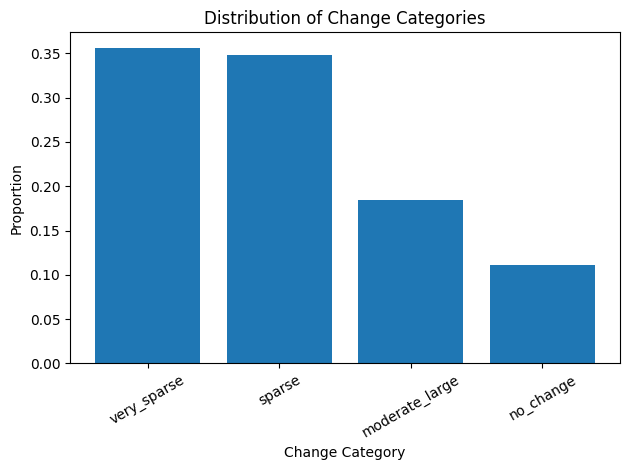

In [9]:
import matplotlib.pyplot as plt

# Data from user
categories = ["very_sparse", "sparse", "moderate_large", "no_change"]
values = [0.356006, 0.347871, 0.184493, 0.111630]

plt.figure()
plt.bar(categories, values)
plt.xlabel("Change Category")
plt.ylabel("Proportion")
plt.title("Distribution of Change Categories")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Stratified train / val / test split

The dataset was divided into subsets for training, validation, and testing. This was done using a stratified sampling strategy. The strategy ensured that each subset had an almost balanced representation of both geographic regions and levels of forest change intensity. This was achieved through using a composite stratification key, where both region and category of change were considered. The dataset was divided into 70%, 15%, and 15% subsets for training, validation, and testing, respectively. This strategy eliminates sampling biases and allows each subset to have an almost balanced representation of no change, sparse, and high change patches.

In [10]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["stratify_key"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["stratify_key"],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

4044 867 867


### Save the splits

In [11]:
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

In [ ]:
# # code to calculate train data mean and std
# train_df = pd.read_csv("/kaggle/working/train_split.csv")
# root_dir = "/kaggle/input/datasets/suranjandas1990/forest-loss-dataset/dataset"

# sum_c = torch.zeros(6)
# sum_sq_c = torch.zeros(6)
# num_pixels = 0

# for _, row in tqdm(train_df.iterrows(), total=len(train_df)):

#     region = row["region"]
#     fname = row["file"]

#     t1 = np.load(f"{root_dir}/{region}/t1/{fname}", mmap_mode="r")
#     t2 = np.load(f"{root_dir}/{region}/t2/{fname}", mmap_mode="r")

#     t1 = torch.tensor(t1, dtype=torch.float32)
#     t2 = torch.tensor(t2, dtype=torch.float32)

#     img = torch.cat([t1, t2], dim=0)  # shape (12, H, W)

#     sum_c += img.sum(dim=[1,2])[:6] + img.sum(dim=[1,2])[6:]
#     sum_sq_c += (img**2).sum(dim=[1,2])[:6] + (img**2).sum(dim=[1,2])[6:]

#     num_pixels += 2 * img.shape[1] * img.shape[2]

# mean = sum_c / num_pixels
# std = torch.sqrt(sum_sq_c / num_pixels - mean**2)

# print("Mean:", mean.tolist())
# print("Std:", std.tolist())

### Dataset and Dataloader

A custom PyTorch dataset class has been developed that facilitates the memory-efficient loading and preprocessing of multi-temporal satellite images. In each batch, there are two types of input images: bi-temporal images (t1 and t2) derived from Sentinel-1 and Sentinel-2 images, and a corresponding binary mask of forest loss. Normalization of input images is done using precomputed mean and standard deviation. NumPy’s memory-mapped arrays are used for memory-efficient loading of images. This allows the model to be trained on large-scale images. The dataset is designed in such a way that it is suitable for Siamese networks, where the model is trained to directly predict change.

In [12]:
data_mean = torch.tensor([0.0187, 0.0389, 0.0231, 0.2954, -8.4814, -14.8727]).view(6,1,1)
data_std = torch.tensor([0.0137, 0.0186, 0.0188, 0.0970, 2.2510, 2.2649]).view(6,1,1)

In [13]:
import torch
from torch.utils.data import Dataset
import numpy as np

class ChangeDataset(Dataset):

    def __init__(self, dataframe, root_dir, mean=data_mean, std=data_std):

        self.df = dataframe.reset_index(drop=True)
        self.root = root_dir

        # dataset mean/std (replace with values computed from your dataset)
        self.mean = mean
        self.std  = std

    def __len__(self):
        return len(self.df)

    def normalize(self, x):
        return (x - self.mean) / (self.std + 1e-6)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        region = row["region"]
        fname = row["file"]

        t1 = np.load(f"{self.root}/{region}/t1/{fname}", mmap_mode="r")
        t2 = np.load(f"{self.root}/{region}/t2/{fname}", mmap_mode="r")
        label = np.load(f"{self.root}/{region}/label/{fname}")

        t1 = torch.tensor(t1, dtype=torch.float32)
        t2 = torch.tensor(t2, dtype=torch.float32)

        t1 = self.normalize(t1)
        t2 = self.normalize(t2)

        label = torch.tensor(label, dtype=torch.float32).unsqueeze(0)

        return t1, t2, label

In [14]:
train_df = pd.read_csv("/kaggle/working/train_split.csv")
val_df = pd.read_csv("/kaggle/working/val_split.csv")

root_dir = "/kaggle/input/datasets/suranjandas1990/forest-loss-dataset/dataset"

train_dataset = ChangeDataset(train_df, root_dir)
val_dataset = ChangeDataset(val_df, root_dir)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=4, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False,
                        num_workers=4, pin_memory=True)

## Model Build and Training

A Siamese U-Net structure, with the addition of Atrous Spatial Pyramid Pooling (ASPP), has been adopted for forest change detection. The proposed network works on pairs of bi-temporal satellite images, using a shared encoder network for hierarchical feature extraction. This ensures that the features are represented in a consistent manner for all time steps. The change information is then derived by finding the absolute difference between the encoded features of the two input images. The ASPP layer has been used for capturing contextual information, which is useful for detecting small-scale as well as large-scale deforestation patterns. The decoder uses skip connections for reconstructing the spatial information, fusing features from both input images. The proposed network has been trained using a hybrid loss function, consisting of Binary Cross-Entropy and Dice Loss. The network has been evaluated using the F1-score and Intersection over Union (IoU) metrics, which are effective for measuring the accuracy of the detection results.

In [15]:
t1, t2, label = train_dataset[0]
t1.shape, t2.shape, label.shape

(torch.Size([6, 256, 256]),
 torch.Size([6, 256, 256]),
 torch.Size([1, 256, 256]))

In [16]:
class DoubleConv(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

In [17]:
class ASPP(nn.Module):

    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv1 = nn.Conv2d(in_ch, out_ch, 1)

        self.conv2 = nn.Conv2d(in_ch, out_ch, 3, padding=6, dilation=6)
        self.conv3 = nn.Conv2d(in_ch, out_ch, 3, padding=12, dilation=12)
        self.conv4 = nn.Conv2d(in_ch, out_ch, 3, padding=18, dilation=18)

        self.project = nn.Conv2d(out_ch * 4, out_ch, 1)

    def forward(self, x):

        f1 = self.conv1(x)
        f2 = self.conv2(x)
        f3 = self.conv3(x)
        f4 = self.conv4(x)

        x = torch.cat([f1, f2, f3, f4], dim=1)

        return self.project(x)

In [18]:
class Encoder(nn.Module):

    def __init__(self, in_channels=6):
        super().__init__()

        self.conv1 = DoubleConv(in_channels, 64)
        self.conv2 = DoubleConv(64, 128)
        self.conv3 = DoubleConv(128, 256)
        self.conv4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):

        f1 = self.conv1(x)
        p1 = self.pool(f1)

        f2 = self.conv2(p1)
        p2 = self.pool(f2)

        f3 = self.conv3(p2)
        p3 = self.pool(f3)

        f4 = self.conv4(p3)
        p4 = self.pool(f4)

        return [f1, f2, f3, f4], p4

In [19]:
class UpBlock(nn.Module):

    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)

        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):

        x = self.up(x)

        x = torch.cat([x, skip], dim=1)

        return self.conv(x)

In [20]:
class SiameseUNet_ASPP(nn.Module):

    def __init__(self, in_channels=6):
        super().__init__()

        self.encoder = Encoder(in_channels)

        self.aspp = ASPP(512, 512)

        self.up4 = UpBlock(512, 1024, 512)
        self.up3 = UpBlock(512, 512, 256)
        self.up2 = UpBlock(256, 256, 128)
        self.up1 = UpBlock(128, 128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, t1, t2):

        feat1, bottleneck1 = self.encoder(t1)
        feat2, bottleneck2 = self.encoder(t2)

        x = torch.abs(bottleneck1 - bottleneck2)

        x = self.aspp(x)

        s4 = torch.cat([feat1[3], feat2[3]], dim=1)
        s3 = torch.cat([feat1[2], feat2[2]], dim=1)
        s2 = torch.cat([feat1[1], feat2[1]], dim=1)
        s1 = torch.cat([feat1[0], feat2[0]], dim=1)

        x = self.up4(x, s4)
        x = self.up3(x, s3)
        x = self.up2(x, s2)
        x = self.up1(x, s1)

        out = self.final(x)

        return out

In [21]:
class DiceLoss(nn.Module):

    def forward(self, pred, target):

        pred = torch.sigmoid(pred)

        smooth = 1e-6

        intersection = (pred * target).sum()

        union = pred.sum() + target.sum()

        dice = (2 * intersection + smooth) / (union + smooth)

        return 1 - dice

In [22]:
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([20]).cuda())
dice = DiceLoss()

def loss_fn(pred, target):
    return 0.5*bce(pred,target) + 0.5*dice(pred,target)

In [23]:
def compute_metrics(pred, target):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.3).float()

    tp = (pred * target).sum()
    fp = (pred * (1-target)).sum()
    fn = ((1-pred) * target).sum()

    precision = tp/(tp+fp+1e-6)
    recall = tp/(tp+fn+1e-6)

    f1 = 2*precision*recall/(precision+recall+1e-6)

    iou = tp/(tp+fp+fn+1e-6)

    return f1.item(), iou.item()

### Training Loop

In [24]:
device = "cuda"

model = SiameseUNet_ASPP()

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = torch.nn.DataParallel(model)

model = model.cuda()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Using 2 GPUs


In [25]:
model

DataParallel(
  (module): SiameseUNet_ASPP(
    (encoder): Encoder(
      (conv1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
        )
      )
      (conv2): DoubleConv(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [ ]:
wandb.init(
    project="Forest loss detection",
    name="unet_aspp_dice_bce",
    config={
        "model": "UNet_ASPP",
        "loss": "Dice+BCE",
        "lr": 1e-4,
        "batch_size": 16,
        "epochs": 50
    }
)

In [ ]:
wandb.watch(model, log="all", log_freq=100)

In [ ]:
best_iou = 0
patience = 5
epochs_without_improvement = 0

scaler = GradScaler(device="cuda")

for epoch in range(50):

    model.train()
    train_loss = 0

    for t1, t2, label in tqdm(train_loader):

        t1 = t1.to(device)
        t2 = t2.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        with autocast(device_type="cuda"):
            pred = model(t1, t2)
            loss = loss_fn(pred, label)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    print("Train loss:", train_loss)

    model.eval()

    f1_scores = []
    ious = []

    with torch.no_grad():

        for t1, t2, label in val_loader:

            t1 = t1.to(device)
            t2 = t2.to(device)
            label = label.to(device)

            with autocast(device_type="cuda"):
                pred = model(t1, t2)

            f1, iou = compute_metrics(pred, label)

            f1_scores.append(f1)
            ious.append(iou)

    val_f1 = np.mean(f1_scores)
    val_iou = np.mean(ious)

    print("Val F1:", val_f1)
    print("Val IoU:", val_iou)

    # Log metrics
    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_f1": val_f1,
        "val_iou": val_iou
    })

    # Save best model
    if val_iou > best_iou:

        best_iou = val_iou
        epochs_without_improvement = 0

        torch.save(model.state_dict(), "best_model.pth")

        artifact = wandb.Artifact(
            name="siamese_unet_model",
            type="model"
        )

        artifact.add_file("best_model.pth")
        wandb.log_artifact(artifact)

        print("Saved new best model")

    else:
        epochs_without_improvement += 1
        print(f"No improvement for {epochs_without_improvement} epochs")

    # Early stopping
    if epochs_without_improvement >= patience:
        print("Early stopping triggered")
        break

wandb.finish()

The model also shows stable convergence with the training loss reducing over the epochs. The performance on the validation set increases over the epochs, with the best F1-score achieved at approximately 0.49 and IoU at approximately 0.33. This confirms the successful learning of meaningful representations of the patterns of change in the forest area. However, the performance plateaus at some epochs, which could be due to the difficulty in detecting the extremely sparse change regions. This can be improved with the development of more effective loss functions and the usage of tec

#### Color	Meaning
Set $NIR=True$ to see false color
- Bright red: Healthy vegetation
- Dark brown: Bare soil / cleared land
- Gray: Urban
- Black: Water

In [ ]:
def stretch(img):

    p2, p98 = np.percentile(img, (2, 98))
    img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)

    return img


def visualize_sample(t1, t2, pred, label, NIR=True):

    t1 = t1.cpu().numpy()
    t2 = t2.cpu().numpy()
    pred = pred.cpu().numpy()
    label = label.cpu().numpy()

    if NIR:
        # False color: NIR-Red-Green
        fc1 = np.stack([t1[3], t1[2], t1[1]], axis=-1)
        fc2 = np.stack([t2[3], t2[2], t2[1]], axis=-1)
    else:
        fc1 = np.stack([t1[2], t1[1], t1[0]], axis=-1)
        fc2 = np.stack([t2[2], t2[1], t2[0]], axis=-1)

    fc1 = stretch(fc1)
    fc2 = stretch(fc2)

    fig, ax = plt.subplots(1,4, figsize=(14,4))

    ax[0].imshow(fc1)
    ax[0].set_title("T1 False Color (NIR-R-G)" if NIR else "T1 (RGB)")
    ax[0].axis("off")

    ax[1].imshow(fc2)
    ax[1].set_title("T2 False Color (NIR-R-G)" if NIR else "T2 (RGB)")
    ax[1].axis("off")

    ax[2].imshow(label, cmap="gray")
    ax[2].set_title("Ground Truth")
    ax[2].axis("off")

    ax[3].imshow(pred, cmap="gray")
    ax[3].set_title("Prediction")
    ax[3].axis("off")

    plt.show()

In [ ]:
# -----------------------
# Load test data
# -----------------------

test_df = pd.read_csv("/kaggle/working/test_split.csv")
root_dir = "/kaggle/input/datasets/suranjandas1990/forest-loss-dataset/dataset"

test_dataset = ChangeDataset(test_df, root_dir)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)


# -----------------------
# Load model
# -----------------------
model = SiameseUNet_ASPP()

state_dict = torch.load("/kaggle/working/best_model.pth", map_location=device)

if "module." in list(state_dict.keys())[0]:
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

model.load_state_dict(state_dict)
model = model.to(device)

model.eval();


In [ ]:
# -----------------------
# Run inference
# -----------------------
num_samples = 8
with torch.no_grad():

    for i, (t1, t2, label) in enumerate(test_loader):

        t1 = t1.to(device)
        t2 = t2.to(device)

        pred = model(t1, t2)

        pred = torch.sigmoid(pred)
        pred = (pred > 0.3).float()

        visualize_sample(
            t1[0],
            t2[0],
            pred[0,0],
            label[0].squeeze(),
            NIR=True
        )

        if i >= num_samples + 1:
            break

## 2. Model Improvement techniques

To improve model performance, several enhancements were incorporated into the training pipeline. Data augmentation techniques such as random flipping and rotation were applied to improve generalization. The loss function was refined by combining Dice Loss with Focal Loss to better handle class imbalance and emphasize hard-to-detect regions. Additionally, dynamic threshold optimization was introduced during validation to maximize F1-score, replacing the fixed threshold approach. A learning rate scheduler was also employed to adaptively reduce the learning rate upon performance stagnation, enabling more stable convergence.

In [ ]:
import torchvision.transforms.functional as TF
import random

class ChangeDataset(Dataset):

    def __init__(self, dataframe, root_dir, mean=data_mean, std=data_std, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.root = root_dir
        self.mean = mean
        self.std = std
        self.augment = augment

    def normalize(self, x):
        return (x - self.mean) / (self.std + 1e-6)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]
        region = row["region"]
        fname = row["file"]

        t1 = np.load(f"{self.root}/{region}/t1/{fname}", mmap_mode="r")
        t2 = np.load(f"{self.root}/{region}/t2/{fname}", mmap_mode="r")
        label = np.load(f"{self.root}/{region}/label/{fname}")

        t1 = torch.tensor(t1, dtype=torch.float32)
        t2 = torch.tensor(t2, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.float32).unsqueeze(0)

        # 🔥 AUGMENTATION
        if self.augment:
            if random.random() > 0.5:
                t1 = TF.hflip(t1)
                t2 = TF.hflip(t2)
                label = TF.hflip(label)

            if random.random() > 0.5:
                t1 = TF.vflip(t1)
                t2 = TF.vflip(t2)
                label = TF.vflip(label)

            if random.random() > 0.5:
                angle = random.choice([90, 180, 270])
                t1 = TF.rotate(t1, angle)
                t2 = TF.rotate(t2, angle)
                label = TF.rotate(label, angle)

        t1 = self.normalize(t1)
        t2 = self.normalize(t2)

        return t1, t2, label

In [ ]:
train_dataset = ChangeDataset(train_df, root_dir, augment=True)
val_dataset   = ChangeDataset(val_df, root_dir, augment=False)

### Focal loss

In [ ]:
class FocalLoss(nn.Module):

    def __init__(self, alpha=0.8, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)

        focal = self.alpha * (1 - pt) ** self.gamma * bce

        return focal.mean()

In [ ]:
focal = FocalLoss()
dice = DiceLoss()

def loss_fn(pred, target):
    return 0.7 * dice(pred, target) + 0.3 * focal(pred, target)

In [ ]:
def compute_best_threshold(preds, targets):

    thresholds = np.arange(0.1, 0.6, 0.05)
    best_f1 = 0
    best_t = 0.3

    for t in thresholds:
        pred_bin = (preds > t).float()

        tp = (pred_bin * targets).sum()
        fp = (pred_bin * (1 - targets)).sum()
        fn = ((1 - pred_bin) * targets).sum()

        precision = tp / (tp + fp + 1e-6)
        recall = tp / (tp + fn + 1e-6)

        f1 = 2 * precision * recall / (precision + recall + 1e-6)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

## Updated training loop

In [ ]:
device = "cuda"

model = SiameseUNet_ASPP()

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = torch.nn.DataParallel(model)

model = model.cuda()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
wandb.init(
    project="Forest loss detection",
    name="unet_aspp_model_improvement",
    config={
        "model": "Siamese_UNet_ASPP",
        "loss": "Dice+Focal",
        "lr": 1e-4,
        "batch_size": 16,
        "epochs": 50
    }
)

In [ ]:
wandb.watch(model, log="all", log_freq=100)

In [ ]:
# ------------------- SETUP -------------------
best_iou = 0
patience = 5
epochs_without_improvement = 0

scaler = GradScaler()

# Optional but recommended
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2,
)

# ------------------- TRAINING -------------------
for epoch in range(50):

    print(f"\nEpoch {epoch+1}/50")

    # -------- TRAIN --------
    model.train()
    train_loss = 0

    for t1, t2, label in tqdm(train_loader):

        t1 = t1.to(device)
        t2 = t2.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        with autocast(device_type="cuda"):
            pred = model(t1, t2)
            loss = loss_fn(pred, label)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    print("Train loss:", train_loss)

    # -------- VALIDATION --------
    model.eval()

    f1_scores = []
    ious = []

    with torch.no_grad():

        for t1, t2, label in val_loader:

            t1 = t1.to(device)
            t2 = t2.to(device)
            label = label.to(device)

            with autocast(device_type="cuda"):
                pred = model(t1, t2)

            f1, iou = compute_metrics(pred, label)

            f1_scores.append(f1)
            ious.append(iou)

    val_f1 = np.mean(f1_scores)
    val_iou = np.mean(ious)

    print("Val F1:", val_f1)
    print("Val IoU:", val_iou)

    # -------- LR Scheduler --------
    scheduler.step(val_iou)

    # -------- W&B LOGGING --------
    wandb.log({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_f1": val_f1,
        "val_iou": val_iou,
        "lr": optimizer.param_groups[0]['lr']
    })

    # -------- SAVE BEST MODEL --------
    if val_iou > best_iou:

        best_iou = val_iou
        epochs_without_improvement = 0

        torch.save(model.state_dict(), "best_model.pth")

        artifact = wandb.Artifact(
            name="siamese_unet_model",
            type="model"
        )

        artifact.add_file("best_model.pth")
        wandb.log_artifact(artifact)

        print("✅ Saved new best model")

    else:
        epochs_without_improvement += 1
        print(f"⚠️ No improvement for {epochs_without_improvement} epochs")

    # -------- EARLY STOPPING --------
    if epochs_without_improvement >= patience:
        print("🛑 Early stopping triggered")
        break

# ------------------- FINISH -------------------
wandb.finish()

## 3. Pretrained Encoder Replacement

### PretrainedSiameseUNet_ASPP — Architecture Overview

`PretrainedSiameseUNet_ASPP` keeps the original `SiameseUNet_ASPP` architecture completely intact — the ASPP bottleneck, all four `UpBlock`s, and the final head are untouched — and only replaces the VGG-style encoder conv blocks with pretrained ResNet-34 layers. ResNet-34 was chosen specifically because its stage output channels (64, 64, 128, 256, 512) match the original encoder channel progression exactly, meaning zero changes are required downstream.

The encoder is split into five explicit stages: `enc0` (conv1 + bn + relu → 64ch at 128×128), `enc1` (maxpool + layer1 → 64ch at 64×64), `enc2` (layer2 → 128ch at 32×32), `enc3` (layer3 → 256ch at 16×16), and `enc4` (layer4 → 512ch at 8×8). Both temporal branches (T1 and T2) share the same encoder object, preserving the Siamese property with a single set of optimized parameters.

The key challenge with pretrained encoders for satellite imagery is the input channel mismatch — ImageNet weights expect 3-channel RGB, while our data has 6 channels (S1 VV/VH + S2 B2/B3/B4/B8). This is resolved by replacing the first conv layer with a new `Conv2d(6, 64, 7×7)` and initializing its weights by averaging the pretrained 3-channel weights across the input dimension and tiling them to cover all 6 channels. This strategy preserves the pretrained spatial filters (edge detectors, texture detectors) in all deeper layers while adapting only the first layer to the new input modality.

The core motivation for this experiment is that training from scratch on 7,500 samples gives the encoder very limited signal to learn good feature representations. A pretrained ResNet-34 encoder starts with weights already tuned to detect low-level structure — edges, textures, gradients — which transfer well to satellite imagery, effectively giving the model a strong initialization and reducing the number of epochs needed to learn meaningful features. The ASPP and decoder remain identical in structure so results are directly comparable to the baseline.

In [ ]:
!pip install segmentation-models-pytorch -q

In [ ]:
import segmentation_models_pytorch as smp

In [ ]:
print(smp.__version__)

In [ ]:
class ASPPModule(nn.Module):
    """
    Self-contained ASPP — no dependency on the existing ASPP class.
    Atrous convolutions at rates 1, 6, 12, 18 + global average pooling.
    in_ch  : input channels  (1024 for our bottleneck)
    out_ch : output channels (1024 to match decoder expectations)
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()

        mid = out_ch // 4   # 256 per branch, 4 branches → 1024 total

        # 1×1 conv
        self.b0 = nn.Sequential(
            nn.Conv2d(in_ch, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        # 3×3 atrous rate=6
        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, mid, 3, padding=6,  dilation=6,  bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        # 3×3 atrous rate=12
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, mid, 3, padding=12, dilation=12, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        # 3×3 atrous rate=18
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, mid, 3, padding=18, dilation=18, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        # Global average pooling branch
        self.gap = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )

        # Project concatenated branches back to out_ch
        self.project = nn.Sequential(
            nn.Conv2d(mid * 5, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Dropout(0.1)
        )

    def forward(self, x):
        h, w   = x.shape[-2:]
        b0     = self.b0(x)
        b1     = self.b1(x)
        b2     = self.b2(x)
        b3     = self.b3(x)
        gap    = F.interpolate(self.gap(x), size=(h, w),
                               mode="bilinear", align_corners=False)
        return self.project(torch.cat([b0, b1, b2, b3, gap], dim=1))

In [ ]:
import torchvision.models as tvm

class PretrainedSiameseUNet_ASPP(nn.Module):

    def __init__(self, in_channels=6, pretrained=True):
        super().__init__()

        backbone = tvm.resnet34(
            weights=tvm.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        )

        # Patch first conv: 3ch → 6ch via weight averaging
        new_conv = nn.Conv2d(in_channels, 64,
                             kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            new_conv.weight = nn.Parameter(
                backbone.conv1.weight.mean(dim=1, keepdim=True)
                .repeat(1, in_channels, 1, 1) / in_channels * 3
            )
        backbone.conv1 = new_conv

        # Encoder stages
        self.enc0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
        self.enc1 = nn.Sequential(backbone.maxpool, backbone.layer1)
        self.enc2 = backbone.layer2
        self.enc3 = backbone.layer3
        self.enc4 = backbone.layer4

        # ASPP bottleneck — using self-contained version, no signature issues
        self.aspp = ASPPModule(in_ch=1024, out_ch=1024)

        # Decoder blocks (identical channel math to original)
        self.dec4 = self._block(1024 + 256 * 2, 512)
        self.dec3 = self._block(512  + 128 * 2, 256)
        self.dec2 = self._block(256  +  64 * 2, 128)
        self.dec1 = self._block(128  +  64 * 2,  64)

        self.head = nn.Conv2d(64, 1, kernel_size=1)

    @staticmethod
    def _block(in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def encode(self, x):
        e0 = self.enc0(x)   # (B,  64, 128, 128)
        e1 = self.enc1(e0)  # (B,  64,  64,  64)
        e2 = self.enc2(e1)  # (B, 128,  32,  32)
        e3 = self.enc3(e2)  # (B, 256,  16,  16)
        e4 = self.enc4(e3)  # (B, 512,   8,   8)
        return e0, e1, e2, e3, e4

    def forward(self, t1, t2):

        t1_e0, t1_e1, t1_e2, t1_e3, t1_e4 = self.encode(t1)
        t2_e0, t2_e1, t2_e2, t2_e3, t2_e4 = self.encode(t2)

        # Bottleneck
        x = self.aspp(torch.cat([t1_e4, t2_e4], dim=1))   # (B,1024, 8, 8)

        # Decode
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec4(torch.cat([x, t1_e3, t2_e3], dim=1))  # (B, 512,16,16)

        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec3(torch.cat([x, t1_e2, t2_e2], dim=1))  # (B, 256,32,32)

        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec2(torch.cat([x, t1_e1, t2_e1], dim=1))  # (B, 128,64,64)

        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec1(torch.cat([x, t1_e0, t2_e0], dim=1))  # (B,  64,128,128)

        x = F.interpolate(x, size=(256, 256), mode="bilinear", align_corners=False)
        return self.head(x)   # (B, 1, 256, 256)

In [ ]:
print("=" * 50)
print("Pretrained ResNet-34 SiameseUNet_ASPP")
print("=" * 50)

model_r34 = PretrainedSiameseUNet_ASPP(in_channels=6, pretrained=True)
count_parameters(model_r34)

dummy_t1 = torch.randn(2, 6, 256, 256)
dummy_t2 = torch.randn(2, 6, 256, 256)

with torch.no_grad():
    out = model_r34(dummy_t1, dummy_t2)

print(f"  Output shape : {out.shape}")
print(f"  Output range : [{out.min():.3f}, {out.max():.3f}]")
# Range must NOT be near zero — should be something like [-2.1, 1.8]

In [ ]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total params    : {total:,}")
    print(f"  Trainable params: {trainable:,}")

In [ ]:
def train_model(model, run_name, encoder_name, epochs=50, lr=1e-4, batch_size=16, patience=5):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2
    )

    scaler = GradScaler()

    # ---------- WandB ----------
    wandb.init(
        project="Forest loss detection",
        name=run_name,
        config={
            "model": f"Siamese_SMP_UNet_{encoder_name}",
            "encoder": encoder_name,
            "loss": "Dice+Focal (0.7/0.3)",
            "lr": lr,
            "batch_size": batch_size,
            "epochs": epochs,
            "pretrained": True,
            "in_channels": 6
        }
    )

    wandb.watch(model, log="all", log_freq=100)

    best_iou = 0
    epochs_without_improvement = 0

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        # -------- TRAIN --------
        model.train()
        train_loss = 0

        for t1, t2, label in tqdm(train_loader, desc="Train"):
            t1     = t1.to(device)
            t2     = t2.to(device)
            label  = label.to(device)

            optimizer.zero_grad()

            with autocast(device_type="cuda"):
                pred = model(t1, t2)
                loss = loss_fn(pred, label)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        print(f"  Train Loss : {train_loss:.4f}")

        # -------- VALIDATION --------
        model.eval()
        f1_scores, ious = [], []

        with torch.no_grad():
            for t1, t2, label in tqdm(val_loader, desc="Val"):
                t1    = t1.to(device)
                t2    = t2.to(device)
                label = label.to(device)

                with autocast(device_type="cuda"):
                    pred = model(t1, t2)

                f1, iou = compute_metrics(pred, label)
                f1_scores.append(f1)
                ious.append(iou)

        val_f1  = np.mean(f1_scores)
        val_iou = np.mean(ious)

        print(f"  Val F1  : {val_f1:.4f}")
        print(f"  Val IoU : {val_iou:.4f}")

        scheduler.step(val_iou)

        # -------- WandB log --------
        wandb.log({
            "epoch"      : epoch + 1,
            "train_loss" : train_loss,
            "val_f1"     : val_f1,
            "val_iou"    : val_iou,
            "lr"         : optimizer.param_groups[0]["lr"]
        })

        # -------- Save best model --------
        if val_iou > best_iou:
            best_iou = val_iou
            epochs_without_improvement = 0

            save_path = f"best_{encoder_name}.pth"
            torch.save(model.state_dict(), save_path)

            artifact = wandb.Artifact(name=f"siamese_smp_{encoder_name}", type="model")
            artifact.add_file(save_path)
            wandb.log_artifact(artifact)

            print(f"  ✅ Best model saved (IoU: {best_iou:.4f})")

        else:
            epochs_without_improvement += 1
            print(f"  ⚠️ No improvement for {epochs_without_improvement} epoch(s)")

        # -------- Early stopping --------
        if epochs_without_improvement >= patience:
            print("  🛑 Early stopping triggered")
            break

    wandb.finish()
    print(f"\nTraining done. Best Val IoU: {best_iou:.4f}")
    return model

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

model_r34 = PretrainedSiameseUNet_ASPP(in_channels=6, pretrained=True)

trained_r34 = train_model(
    model        = model_r34,
    run_name     = "siamese_resnet34_pretrained",
    encoder_name = "resnet34_pretrained",
    epochs       = 50,
    lr           = 1e-4,
    patience     = 5
)

ResNet-34 / ResNet-50 encoder via segmentation_models_pytorch (smp)
The easiest and most proven swap. You keep your Siamese structure but replace both branches with a pretrained ResNet encoder. The library handles skip connections automatically. ResNet-34 is very GPU-friendly and has strong transfer learning for satellite imagery.

## 4. Architecture Modifications on Top of Existing Model


 ─────────────────────────────────────────────────────────────────────────────
## SiameseUNet_V2 — Architecture Overview
─────────────────────────────────────────────────────────────────────────────

SiameseUNet_V2 builds directly on top of the original SiameseUNet_ASPP by
keeping the encoder and ASPP completely unchanged and injecting three targeted
improvements into the decoder path.

(1) TEMPORAL BOTTLENECK FUSION — Before entering the ASPP, the deepest features from both temporal branches (T1 and T2) are concatenated (1024ch) and projected back to 512ch via a 1×1 Conv-BN-ReLU block. This makes the bottleneck representation temporally aware before multiscale feature extraction, unlike the original where ASPP processed only one branch.

(2) ATTENTION GATES + CHANGE FEATURE FUSION (inside UpBlockV2) — Each skip connection from the encoder is passed through a dedicated Attention Gate before reaching the decoder. The gate uses the upsampled decoder feature as a gating signal and learns a soft spatial mask (values 0–1) that suppresses background activations and highlights regions likely showing change — critical given that ~89% of pixels in our dataset are unchanged. After gating, both temporal skips are passed through a ChangeFusion module which explicitly computes [t1, t2, |t1−t2|, t1×t2], concatenates them (4×ch), and projects back to 2×ch. This gives the decoder an explicit change signal (magnitude of difference + feature correlation) instead of requiring it to infer change implicitly from raw concatenated features — directly addressing weak signals from small Jhum patches and sparse deforestation. 

(3) DEEP SUPERVISION — Three lightweight auxiliary heads (1×1 Conv2d) are attached to intermediate decoder outputs d4, d3, and d2. Each produces a full-resolution prediction (upsampled to 256×256) that contributes to the total loss with weights 0.4, 0.2, and 0.1 respectively, while the main head retains weight 1.0. This injects gradient signal directly into early decoder layers, preventing the training plateau seen at epoch 25–30 in previous runs where gradients from the final loss were too weak to effectively update those layers. All auxiliary heads are active only during training (self.training guard) and are completely bypassed at inference, adding zero overhead.

Channel dimensions at every decoder level are identical to the original model,
 making V2 a strict superset — same architecture, richer skip connections.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# 1. Attention Gate (Attention U-Net style)
# ─────────────────────────────────────────────────────────────────
class AttentionGate(nn.Module):
    """
    Standard soft attention gate.
    g : gating signal  — upsampled decoder feature  (lower resolution source)
    x : skip connection — encoder feature            (higher resolution)
    Returns x weighted by a spatial attention map.
    """
    def __init__(self, g_ch, x_ch, inter_ch):
        super().__init__()
        self.Wg  = nn.Sequential(
            nn.Conv2d(g_ch,    inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch)
        )
        self.Wx  = nn.Sequential(
            nn.Conv2d(x_ch,    inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1,       kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

    def forward(self, g, x):
        # Upsample gating signal to match skip spatial size
        g_up = F.interpolate(
            self.Wg(g), size=x.shape[-2:],
            mode="bilinear", align_corners=False
        )
        att = self.psi(F.relu(g_up + self.Wx(x), inplace=True))
        return x * att          # attended skip


# ─────────────────────────────────────────────────────────────────
# 2. Change Feature Fusion Module
# ─────────────────────────────────────────────────────────────────
class ChangeFusion(nn.Module):
    """
    Given T1 and T2 skip features, computes four representations:
        [t1, t2, |t1-t2|, t1*t2]  (4 × ch)
    and projects back to 2 × ch so decoder channel dims stay identical.
    """
    def __init__(self, ch):
        super().__init__()
        self.project = nn.Sequential(
            nn.Conv2d(ch * 4, ch * 2, kernel_size=1, bias=False),
            nn.BatchNorm2d(ch * 2),
            nn.ReLU(inplace=True)
        )

    def forward(self, t1, t2):
        diff   = torch.abs(t1 - t2)
        prod   = t1 * t2
        concat = torch.cat([t1, t2, diff, prod], dim=1)   # 4×ch
        return self.project(concat)                         # 2×ch


# ─────────────────────────────────────────────────────────────────
# 3. Enhanced UpBlock  (replaces original UpBlock)
# ─────────────────────────────────────────────────────────────────
class UpBlockV2(nn.Module):
    """
    Drop-in replacement for original UpBlock.
    Adds: Attention Gate on each temporal skip  +  Change Fusion.

    Channel arithmetic (identical to original UpBlock):
        ConvTranspose(up_in → up_out)
        cat[upsampled, ChangeFusion(t1_skip, t2_skip)]
            = up_out + skip_ch*2   →  DoubleConv  →  up_out
    """
    def __init__(self, up_in_ch, up_out_ch, skip_ch):
        super().__init__()

        inter_ch = max(skip_ch // 2, 16)

        self.up          = nn.ConvTranspose2d(up_in_ch, up_out_ch,
                                              kernel_size=2, stride=2)
        self.att_t1      = AttentionGate(g_ch=up_out_ch, x_ch=skip_ch,
                                         inter_ch=inter_ch)
        self.att_t2      = AttentionGate(g_ch=up_out_ch, x_ch=skip_ch,
                                         inter_ch=inter_ch)
        self.change_fuse = ChangeFusion(ch=skip_ch)          # output: 2×skip_ch
        self.conv        = DoubleConv(up_out_ch + skip_ch * 2, up_out_ch)

    def forward(self, x, t1_skip, t2_skip):
        x = self.up(x)                                        # upsample

        # Spatial safety (handles any off-by-one from odd dimensions)
        if x.shape[-2:] != t1_skip.shape[-2:]:
            x = F.interpolate(x, size=t1_skip.shape[-2:],
                              mode="bilinear", align_corners=False)

        # Attention on each temporal skip (gate = upsampled decoder feature)
        t1_att = self.att_t1(g=x, x=t1_skip)
        t2_att = self.att_t2(g=x, x=t2_skip)

        # Change feature fusion → 2×skip_ch
        fused = self.change_fuse(t1_att, t2_att)

        return self.conv(torch.cat([x, fused], dim=1))

In [ ]:
class SiameseUNet_V2(nn.Module):
    """
    Original SiameseUNet_ASPP + three improvements applied together:

        1. Attention Gates   — suppress irrelevant skip activations
        2. Change Fusion     — explicit |f1-f2| and f1*f2 at each skip level
        3. Deep Supervision  — auxiliary loss heads at up4, up3, up2 levels

    All channel dimensions are identical to the original model.
    Encoder and ASPP blocks are reused as-is.
    """

    def __init__(self, in_channels=6):
        super().__init__()

        # ── Encoder  (exactly same as original) ──────────────────────────
        self.encoder = Encoder(in_channels)

        # ── Bottleneck fusion before ASPP ────────────────────────────────
        # Original ASPP takes 512ch.
        # We concat t1_e4 + t2_e4 = 1024ch, project → 512, then ASPP.
        # This gives ASPP access to BOTH temporal branches at bottleneck.
        self.bottleneck_fusion = nn.Sequential(
            nn.Conv2d(1024, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

        # ── ASPP  (exactly same as original) ─────────────────────────────
        self.aspp = ASPP(512,512)

        # ── Enhanced decoder blocks ───────────────────────────────────────
        #   up4 : aspp(512)  + e4_skips(512 each)  → 512
        #   up3 : up4(512)   + e3_skips(256 each)  → 256
        #   up2 : up3(256)   + e2_skips(128 each)  → 128
        #   up1 : up2(128)   + e1_skips(64  each)  → 64
        self.up4 = UpBlockV2(up_in_ch=512, up_out_ch=512, skip_ch=512)
        self.up3 = UpBlockV2(up_in_ch=512, up_out_ch=256, skip_ch=256)
        self.up2 = UpBlockV2(up_in_ch=256, up_out_ch=128, skip_ch=128)
        self.up1 = UpBlockV2(up_in_ch=128, up_out_ch=64,  skip_ch=64)

        # ── Main output head ──────────────────────────────────────────────
        self.final = nn.Conv2d(64, 1, kernel_size=1)

        # ── Deep supervision heads (only used during training) ────────────
        self.aux_head4 = nn.Conv2d(512, 1, kernel_size=1)
        self.aux_head3 = nn.Conv2d(256, 1, kernel_size=1)
        self.aux_head2 = nn.Conv2d(128, 1, kernel_size=1)

    # ── Encode one temporal image ─────────────────────────────────────────
    def _encode(self, x):
        e1 = self.encoder.conv1(x)                       # 64,  256×256
        e2 = self.encoder.conv2(self.encoder.pool(e1))   # 128, 128×128
        e3 = self.encoder.conv3(self.encoder.pool(e2))   # 256,  64×64
        e4 = self.encoder.conv4(self.encoder.pool(e3))   # 512,  32×32
        return e1, e2, e3, e4

    def forward(self, t1, t2):

        # ── Encode ────────────────────────────────────────────────────────
        t1_e1, t1_e2, t1_e3, t1_e4 = self._encode(t1)
        t2_e1, t2_e2, t2_e3, t2_e4 = self._encode(t2)

        # ── Bottleneck ────────────────────────────────────────────────────
        # Pool both → concat → project 1024→512 → ASPP
        pooled = self.encoder.pool(
            self.bottleneck_fusion(
                torch.cat([t1_e4, t2_e4], dim=1)          # 1024, 32×32
            )
        )                                                   # 512,  16×16
        x = self.aspp(pooled)                              # 512,  16×16

        # ── Decode with attention + change fusion ─────────────────────────
        d4 = self.up4(x,  t1_e4, t2_e4)                   # 512,  32×32
        d3 = self.up3(d4, t1_e3, t2_e3)                   # 256,  64×64
        d2 = self.up2(d3, t1_e2, t2_e2)                   # 128, 128×128
        d1 = self.up1(d2, t1_e1, t2_e1)                   # 64,  256×256

        # ── Main prediction ───────────────────────────────────────────────
        main_out = self.final(d1)                           # 1, 256×256

        # ── Auxiliary predictions (deep supervision) ──────────────────────
        # Upsample each to 256×256 for loss computation
        if self.training:
            aux4 = F.interpolate(
                self.aux_head4(d4), size=(256, 256),
                mode="bilinear", align_corners=False
            )
            aux3 = F.interpolate(
                self.aux_head3(d3), size=(256, 256),
                mode="bilinear", align_corners=False
            )
            aux2 = F.interpolate(
                self.aux_head2(d2), size=(256, 256),
                mode="bilinear", align_corners=False
            )
            return main_out, aux4, aux3, aux2

        return main_out     # inference: single output only

In [ ]:
def loss_fn_v2(preds, target):
    """
    During training : preds = (main, aux4, aux3, aux2)
    During inference: preds = main tensor directly
    
    Weights: main=1.0, aux4=0.4, aux3=0.2, aux2=0.1
    (deeper auxiliaries get lower weight — they see less context)
    """
    if isinstance(preds, tuple):
        main, aux4, aux3, aux2 = preds
        loss  = 1.0 * loss_fn(main, target)
        loss += 0.4 * loss_fn(aux4, target)
        loss += 0.2 * loss_fn(aux3, target)
        loss += 0.1 * loss_fn(aux2, target)
        return loss
    return loss_fn(preds, target)

In [ ]:
def compute_metrics_v2(preds, target, threshold=0.5):
    """Works whether preds is a tuple (training) or tensor (eval)."""
    if isinstance(preds, tuple):
        preds = preds[0]   # use main output only for metrics
    return compute_metrics(preds, target, threshold)

In [ ]:
print("=" * 50)
print("SiameseUNet_V2  (Attn + ChangeFusion + DeepSup)")
print("=" * 50)

model_v2 = SiameseUNet_V2(in_channels=6)
count_parameters(model_v2)

dummy_t1 = torch.randn(2, 6, 256, 256)
dummy_t2 = torch.randn(2, 6, 256, 256)

model_v2.train()
with torch.no_grad():
    out_train = model_v2(dummy_t1, dummy_t2)

print(f"  Training output  : {type(out_train)} — {len(out_train)} tensors")
for i, o in enumerate(out_train):
    print(f"    [{i}] shape={o.shape}  range=[{o.min():.2f}, {o.max():.2f}]")

model_v2.eval()
with torch.no_grad():
    out_eval = model_v2(dummy_t1, dummy_t2)

print(f"\n  Eval output shape: {out_eval.shape}")
print(f"  Eval range       : [{out_eval.min():.2f}, {out_eval.max():.2f}]")

In [ ]:
import gc
torch.cuda.empty_cache()
gc.collect()

model_v2 = SiameseUNet_V2(in_channels=6)

wandb.init(
    project="Forest loss detection",
    name="siamese_v2_attn_changefusion_deepsup",
    config={
        "model"       : "SiameseUNet_V2",
        "improvements": ["AttentionGates", "ChangeFusion", "DeepSupervision"],
        "loss"        : "Dice+Focal (0.7/0.3) with deep supervision",
        "lr"          : 1e-4,
        "batch_size"  : 16,
        "epochs"      : 50
    }
)

wandb.watch(model_v2, log="all", log_freq=100)

device     = "cuda" if torch.cuda.is_available() else "cpu"
model_v2   = model_v2.to(device)
optimizer  = torch.optim.Adam(model_v2.parameters(), lr=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                 optimizer, mode='max', factor=0.5, patience=2)
scaler     = GradScaler()
best_iou   = 0
no_improve = 0
PATIENCE   = 5

for epoch in range(50):
    print(f"\nEpoch {epoch+1}/50")

    # ── Train ──────────────────────────────────────────────────────
    model_v2.train()
    train_loss = 0

    for t1, t2, label in tqdm(train_loader, desc="Train"):
        t1, t2, label = t1.to(device), t2.to(device), label.to(device)
        optimizer.zero_grad()

        with autocast(device_type="cuda"):
            preds = model_v2(t1, t2)          # tuple during training
            loss  = loss_fn_v2(preds, label)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    print(f"  Train Loss : {train_loss:.4f}")

    # ── Validate ───────────────────────────────────────────────────
    model_v2.eval()
    f1_scores, ious = [], []

    with torch.no_grad():
        for t1, t2, label in tqdm(val_loader, desc="Val"):
            t1, t2, label = t1.to(device), t2.to(device), label.to(device)
            with autocast(device_type="cuda"):
                pred = model_v2(t1, t2)       # tensor during eval
            f1, iou = compute_metrics(pred, label)
            f1_scores.append(f1)
            ious.append(iou)

    val_f1  = np.mean(f1_scores)
    val_iou = np.mean(ious)
    print(f"  Val F1  : {val_f1:.4f}")
    print(f"  Val IoU : {val_iou:.4f}")

    scheduler.step(val_iou)

    wandb.log({
        "epoch"      : epoch + 1,
        "train_loss" : train_loss,
        "val_f1"     : val_f1,
        "val_iou"    : val_iou,
        "lr"         : optimizer.param_groups[0]["lr"]
    })

    if val_iou > best_iou:
        best_iou   = val_iou
        no_improve = 0
        torch.save(model_v2.state_dict(), "best_v2.pth")
        artifact = wandb.Artifact(name="siamese_unet_v2", type="model")
        artifact.add_file("best_v2.pth")
        wandb.log_artifact(artifact)
        print(f"  ✅ Best model saved (IoU: {best_iou:.4f})")
    else:
        no_improve += 1
        print(f"  ⚠️  No improvement for {no_improve} epoch(s)")

    if no_improve >= PATIENCE:
        print("  🛑 Early stopping triggered")
        break

wandb.finish()
print(f"\nDone. Best Val IoU: {best_iou:.4f}")